In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import statsmodels.api as sm
import pickle as pkl
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [2]:
num_group = 8

df_1 = pkl.load(open(r"C:\Users\arada\Desktop\אוניברסיטה\הנדסה תעשייה וניהול\שנה ג\סמסטר ב\ניהול בטיחות למהנדסים\פרויקט\חלק 1\df_task_1_group_8.pkl", 'rb'))
df_1.head()

,age,expirience,hour,worker_rank,days_c,toys_c,factories_rand_c,months_c,safety_event
0,24,7,4,3,Tuesday,spinner,Huainan,August,1
1,24,5,6,2,Wednesday,spinner,Huangshan,December,0
2,21,9,4,4,Wednesday,spinner,Anqing,September,1
3,22,8,1,4,Wednesday,spinner,Bengbu,August,0
4,22,3,6,1,Wednesday,spinner,Huangshan,February,0


<div dir="rtl">

### ברוכים הבאים לפרויקט גמר
    
### בחלק הראשון נעסוק בתאונות של עובדים במפעלי צעצועים בסין. 
    
### במפעלים אלו הפועלים עובדים שעות ארוכות עם מכונות מסוכנות והרבה מהם נפצעים במהלך עבודתם. 
    
### בחלק הראשון של הפרויקט נרצה למצוא את ההסתברות לפציעה של עובד.
    
### יש לנו מספר משתנים מסבירים: 

In [3]:
df_1.columns

Index(['age', 'expirience', 'hour', 'worker_rank', 'days_c', 'toys_c',
       'factories_rand_c', 'months_c', 'safety_event'],
      dtype='object')

* age: the worker age (numeric)
* expirience: the number of years the worker is in the factory (numeric)
* hour: the hour of the shift: 1-12 (numeric)
* worker_rank: workers are being ranked by their employer, the higher the rank the most senior the worker is. Ranks are between 0 to 5 (numeric)
* days: day of the week (categorical)
* toys: the type of the toy (categorical)
* factory: the factory location refers to a city in china (categorical)
* month: the month in the year (categorical)
* safety_event: 1 if an accidents accured, 0 if not.

<div dir="rtl">

## לפניך מספר מטלות: 
    
### 1. להציג scatter plot עבור כל זוג משתנים מסבירים רציפים (לא קטגוריאלים) ולחשב קורלציה (r) בין כל זוג. האם יש זוג משתנים שיש בינהם קשר? אם כן, אילו? 

### 2. בחרו שני משתנים קטגוריאליים. 
### הציגו בשני גרפים שונים את מספר העובדים שעברו תאונה לעומת אלו שלא עברו תאונה (בצבעים שונים תאונה לעומת לא תאונה), עבור כל אחת מהקטגוריות בנפרד. 
### עבור כל אחד מהמשתנים בדקו האם אתם מזהים קטגוריה מסוימת שעבורה יש יותר סיכוי לתאונה בהשוואה לקטגוריות האחרות שבאותו משתנה? 
### אם כן, מהי אותה קטגוריה בכל אחד מהמשתנים שבחרתם? 
### בהתחשב בתשובתכם, מה לדעתכם הסבירות שהמקדמים של המשתנים שבחרתם יהיו מובהקים כחלק מרגרסיה לוגיסטית?
    
### 3. הציגו בגרף של שני עמודות את מספר התאונות לעומת לא-תאונות עבור כלל העובדים. חשבו את השכיחות היחסית לתאונה וללא תאונה.
    
### 4. נא להוציא הסטוגרמה של אחד המשתנים הרציפים. יש להסביר במשפט מה הנתונים מה מציגים (טווח, היכן יש ריכוז גבוה וכו')
    
### 5. לפני שמתחילים את הניתוח הלוגיסטי - נא לפצל את כל הנתונים לtrain -ו test לפי יחס של 30-70
    
### 6. יש למצוא את המודל של הרגרסיה הלוגיסטית עבור המודל המתקבל מstepwise selection. נא להשוות ערכים של AIC וBIC נגד המודל בו כל המשתנים נכנסים למודל.     

## עבור סעיפים 7-11 נא להשתמש במודל שהתקבל על ידי הstepwise selection.
    
### 7. מה הסיכוי לתאונה עבור מצב שכל משתני הדמה במצב בסיס שלהם וכל המשתנים הרציפים עם הערך 2?
    
### 8. נרצה כעת להשוות בין 2 קבוצות שונות של משתנה קטוגיריאלי כפונקציה של כל הערכים האפשריים של משתנה רציף כלשהו. יש לחשב את ההסתברות לתאונה עבור כל אחת מהקבוצות כאשר הערכים של שאר המשתנים קבועים. עבור שאר המשתנים הקטוגוריאלים תזינו למודל את הערך 0  ואילו עבור משתנים רציפים אחרים תזינו את ההממוצע מהtrain set. 
    
### 9. עם אותם נתונים של סעיף 8, יש לחשב את הlog odds ratio בין 2 הקבוצות של המשתנה הקטגוריאלי שבחרתם עבור הרבה ערכים של המשתנה הרציף. כיצד הגרף נראה? נא להסביר את התוצאה? מה משמעות הערך שקיבלתם בגרף?
    
### סעיפים 10-12 מתייחסים לtest set.    

### 10. מהו הערך סף המינימלי כך שה-sensitivity יהיה לפחות 0.8? יש לעשות זאת עבור הtest set?
    
### 11. יש להוציא ROC curve עבור המודל הסופי ולחשב את הAUC. 

### 12. יש להוציא עוד שני ROC curves. פעם אחת כאשר אתם מוציאים משתנה רציף אחד ופעם שנייה כאשר אתם מוציאים משתנה קטגוריאלי. יש להכניס את כל הROC curves כולל את העקומה מסעיף 11 ולשים בגרף אחד. יש להשוות בין שלוש ה-AUC? מה קרה לAUC אחרי שהוצאתם את המשתנה הרציף ואחרי שהוצאתם את המשתנה הקטוגוריאלי? מי הושפע יותר ? מה זה אומר לדעתכם?
    
    
### בהצלחה
    
    

Matrix for numeric variables:
                  age  expirience      hour  worker_rank
age          1.000000   -0.024591  0.024920    -0.027804
expirience  -0.024591    1.000000 -0.034012     0.984532
hour         0.024920   -0.034012  1.000000    -0.032034
worker_rank -0.027804    0.984532 -0.032034     1.000000




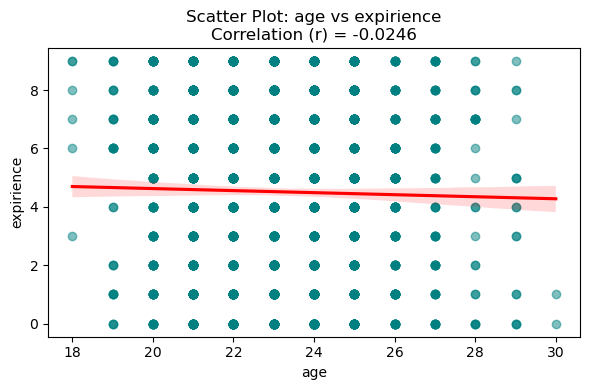

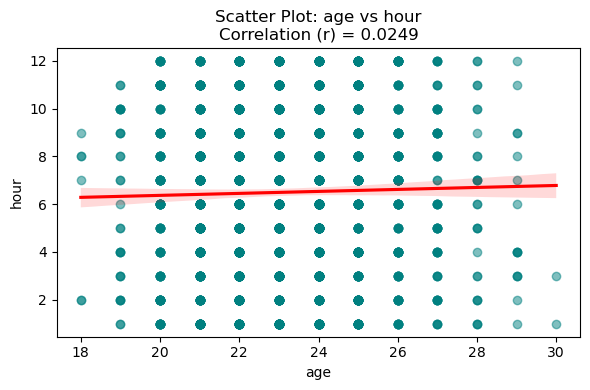

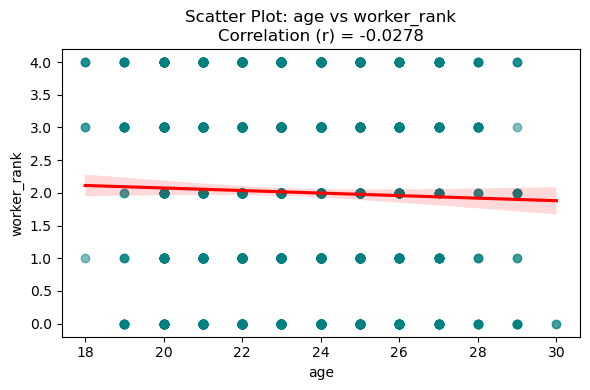

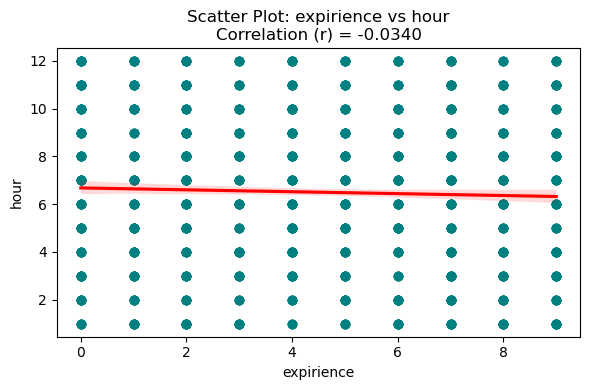

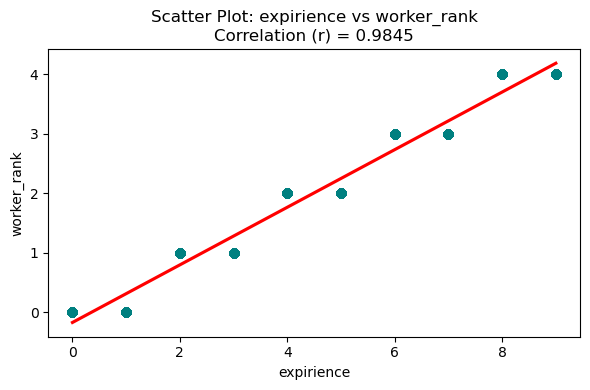

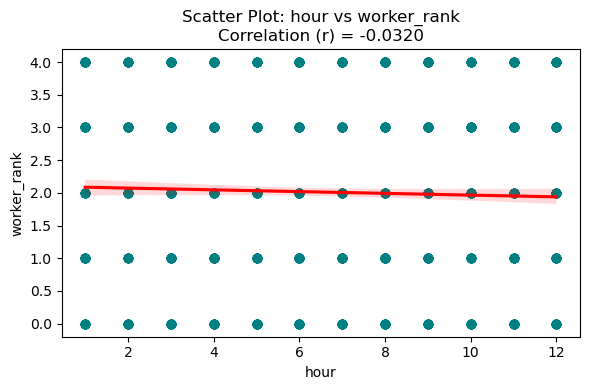

In [4]:
cols_numeric = ['age', 'expirience', 'hour', 'worker_rank']

numeric_corr = df_1[cols_numeric].corr()

print("Matrix for numeric variables:")
print(numeric_corr)
print("\n" + "="*50 + "\n")

num_cols = len(cols_numeric)

for i in range(num_cols):
    for j in range(i + 1, num_cols):
        var1 = cols_numeric[i]
        var2 = cols_numeric[j]
        
        correlation_value = numeric_corr.loc[var1, var2]
        plt.figure(figsize=(6, 4))
        sns.regplot(
            data=df_1, 
            x=var1, 
            y=var2, 
            scatter_kws={'alpha':0.5, 'color': 'teal'}, 
            line_kws={'color': 'red'}
        )
        
        plt.title(f"Scatter Plot: {var1} vs {var2}\nCorrelation (r) = {correlation_value:.4f}", fontsize=12)
        plt.xlabel(var1)
        plt.ylabel(var2)
        
        plt.tight_layout()
        plt.show() 

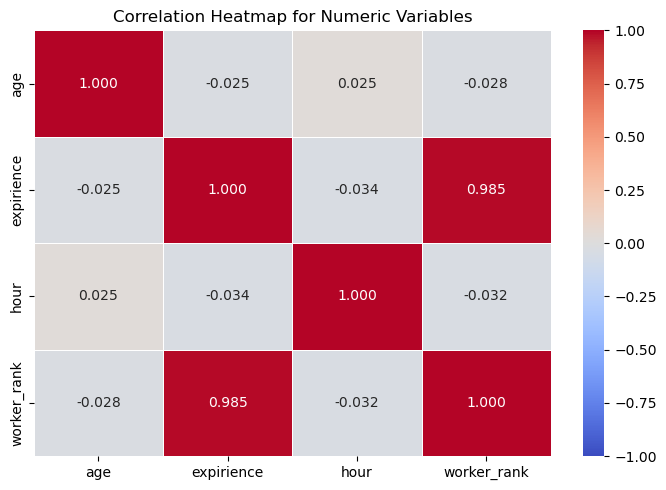

In [5]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    numeric_corr, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".3f",           
    vmin=-1,             
    vmax=1,             
    linewidths=0.5       
)

plt.title("Correlation Heatmap for Numeric Variables", fontsize=12)
plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
         ניתוח קשרים ומתאמים בין המשתנים הרציפים
    </h3>

<div style="margin-bottom: 20px;">
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            זוג המשתנים בעל קשר חזק:
        </span>
<p style="margin: 0; text-align: justify;">
            קיים קשר חיובי חזק מאוד, כמעט מושלם, בין <b>שנות ניסיון (<code>expirience</code>)</b> לבין <b>דרגת העובד (<code>worker_rank</code>)</b> עם מקדם מתאם של <b>r = 0.985</b>, המעיד כי ככל שהניסיון עולה, הדרגה עולה בצורה ישירה ועקבית.
        </p>
    </div>

<div>
        <span style="display: block; font-weight: bold; color: #2c3e50; font-size: 1.1em; margin-bottom: 6px;">
            יתר זוגות המשתנים:
        </span>
        <p style="margin: 0; text-align: justify;">
            עבור כל שאר המשתנים (גיל, שעות וניסיון) מקדמי המתאם קרובים מאוד ל-0 (בטווח שבין 0.03- ל-0.03), דבר המעיד על היעדר קשר ליניארי ומסביר את פיזור הנתונים האקראי שקיבלנו בגרפים.
        </p>
    </div>

</div>

Accident rate by toy type:
               accidents  total    rate
toys_c                                 
electric_toys        104    145  0.7172
spinner              858   1520  0.5645
toy_cars              96    173  0.5549
dolls                 25     46  0.5435
puzzels               62    116  0.5345



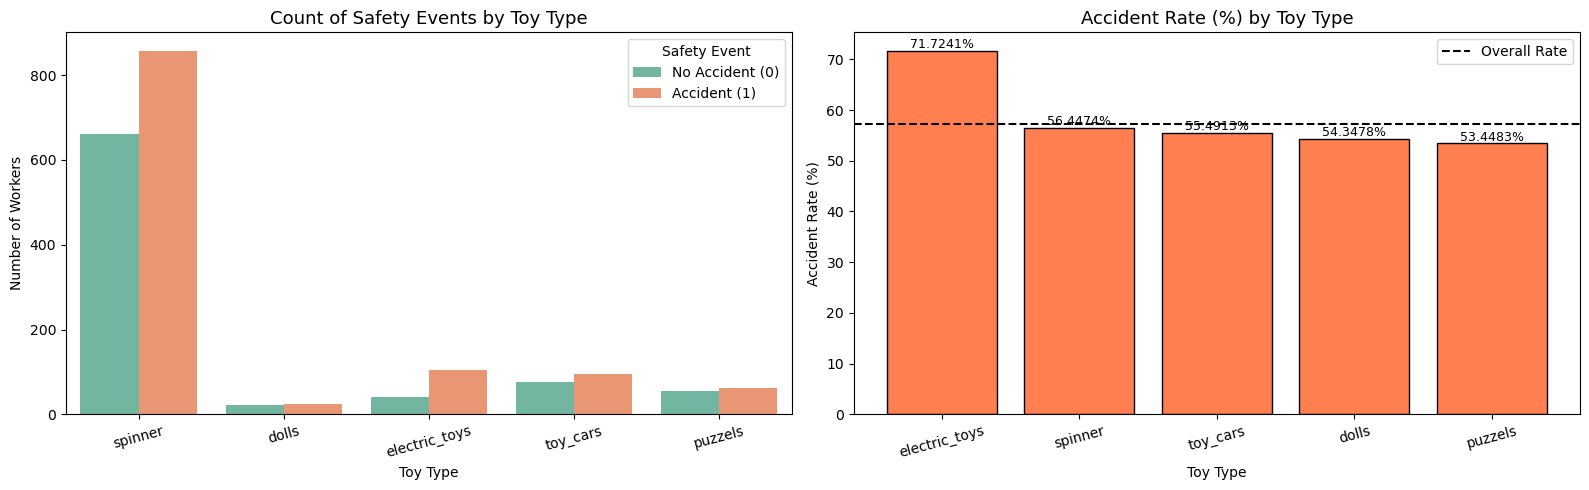

In [6]:
toy_rates = df_1.groupby('toys_c')['safety_event'].mean().sort_values(ascending=False)
toy_counts = df_1.groupby('toys_c')['safety_event'].agg(['sum','count'])
toy_counts.columns = ['accidents', 'total']
toy_counts['rate'] = (toy_counts['accidents'] / toy_counts['total']).round(4)
print("Accident rate by toy type:")
print(toy_counts.sort_values('rate', ascending=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df_1, x='toys_c', hue='safety_event', palette='Set2', ax=axes[0])
axes[0].set_title("Count of Safety Events by Toy Type", fontsize=13)
axes[0].set_xlabel("Toy Type")
axes[0].set_ylabel("Number of Workers")
axes[0].legend(title="Safety Event", labels=["No Accident (0)", "Accident (1)"])
axes[0].tick_params(axis='x', rotation=15)

bars = axes[1].bar(toy_rates.index, toy_rates.values * 100, color='coral', edgecolor='black')
axes[1].set_title("Accident Rate (%) by Toy Type", fontsize=13)
axes[1].set_xlabel("Toy Type")
axes[1].set_ylabel("Accident Rate (%)")
axes[1].tick_params(axis='x', rotation=15)
axes[1].axhline(y=df_1['safety_event'].mean()*100, color='black', linestyle='--', label='Overall Rate')
axes[1].legend()
for bar, val in zip(bars, toy_rates.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.4f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Accident rate by month:
           accidents  total    rate
months_c                           
January           53     86  0.6163
February          93    159  0.5849
March             12     21  0.5714
April             84    147  0.5714
May               68    100  0.6800
June              43     82  0.5244
July             112    195  0.5744
August           479    891  0.5376
September        101    143  0.7063
November          49     78  0.6282
December          51     98  0.5204

Note: October has no data at all in the dataset.


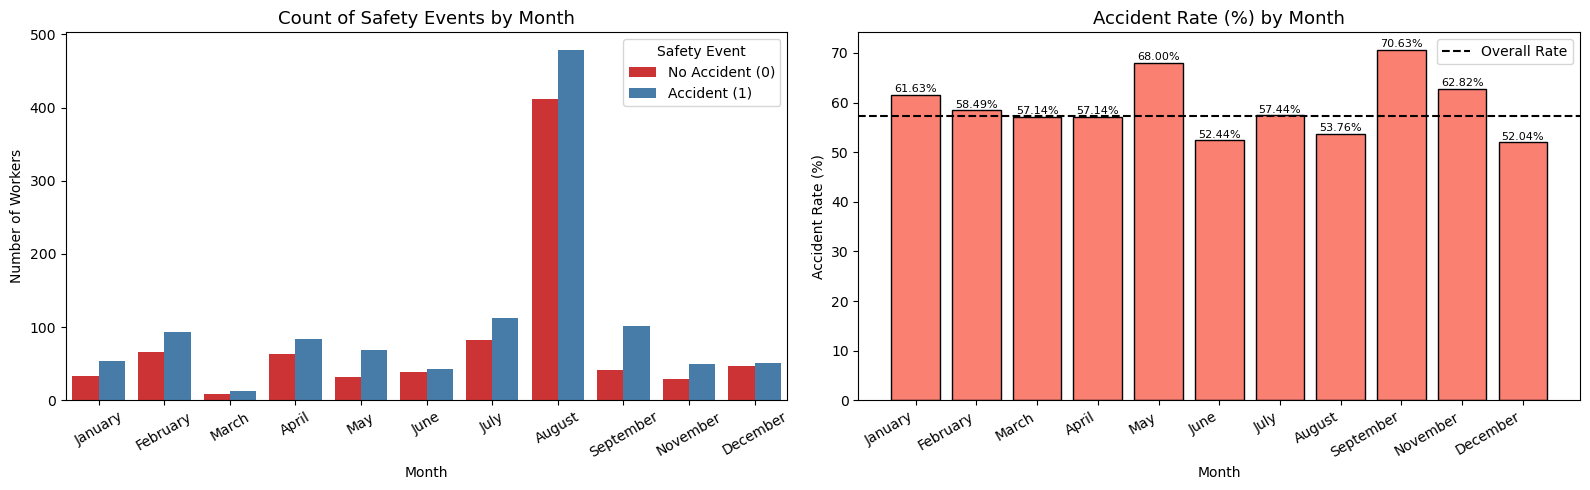

In [7]:
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

existing_months = [m for m in months_order if m in df_1['months_c'].values]

month_rates = df_1.groupby('months_c')['safety_event'].mean().reindex(existing_months)
month_counts = df_1.groupby('months_c')['safety_event'].agg(['sum','count']).reindex(existing_months)
month_counts.columns = ['accidents', 'total']
month_counts['rate'] = (month_counts['accidents'] / month_counts['total']).round(4)
print("Accident rate by month:")
print(month_counts)
print()
print("Note: October has no data at all in the dataset.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw count
sns.countplot(data=df_1, x='months_c', hue='safety_event', order=existing_months, palette='Set1', ax=axes[0])
axes[0].set_title("Count of Safety Events by Month", fontsize=13)
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Workers")
axes[0].legend(title="Safety Event", labels=["No Accident (0)", "Accident (1)"])
axes[0].tick_params(axis='x', rotation=30)

# Right: accident rate
bars = axes[1].bar(range(len(existing_months)), month_rates.values * 100, color='salmon', edgecolor='black')
axes[1].set_xticks(range(len(existing_months)))
axes[1].set_xticklabels(existing_months, rotation=30, ha='right')
axes[1].set_title("Accident Rate (%) by Month", fontsize=13)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Accident Rate (%)")
axes[1].axhline(y=df_1['safety_event'].mean()*100, color='black', linestyle='--', label='Overall Rate')
axes[1].legend()
for bar, val in zip(bars, month_rates.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            זיהוי קטגוריה בעלת השפעה על התאונות - סוגי צעצועים (`toys_c`)
        </h3>
        <p style="margin: 0; text-align: justify;">
            קטגוריית ה<b>ספינר</b> בולטת בכמות התאונות הגבוהה ביותר, אך זאת בשל היותה הקטגוריה הגדולה ביותר. כאשר בוחנים את שיעור התאונות, דווקא קטגוריית <b>electric_toys</b> בולטת עם שיעור של 71.72%, בהשוואה ל-56.45% בלבד אצל הספינר.
        </p>
    </div>

<div>
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            זיהוי קטגוריה בעלת השפעה על התאונות - חודשי השנה (`months_c`)
        </h3>
        <p style="margin: 0 0 10px 0; text-align: justify;">
חודש <b>אוגוסט</b> בולט בכמות המוחלטת הגבוהה ביותר, אך שיעור התאונות בו הוא רק 53.76%. החודשים בעלי שיעור התאונות הגבוה ביותר הם ספטמבר (70.63%) ומאי (68.00%).        </p>
        <p style="margin: 0; text-align: justify;">
            <b>העשרה -</b> <b>על פי הגרף ניתן לראות שבחודש אוקטובר אין בכלל תאונות או לא תאונות. ביצענו בדיקה וראינו שאין מידע על עבודה כלל בחודש זה.</b> 
        </p>
    </div>

</div>

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 20px;">
        מובהקות המקדמים הצפויה ברגרסיה לוגיסטית
    </h3>

<div style="margin-bottom: 20px;">
        <p style="margin: 0; text-align: justify;">
בניתוח הגרפי זיהינו פער משמעותי בשיעור התאונות של קטגוריית <b>electric_toys</b> (71.72%) בהשוואה ליתר הצעצועים (53.45%–56.45%). מאחר שהבדל זה ניכר, מודל הרגרסיה הלוגיסטית צפוי לזהות את הקשר ולתרגם אותו למקדם מובהק סטטיסטית (<i>p</i> &lt; 0.05). 
        </p>
    </div>

<div>
        <p style="margin: 0; text-align: justify;">
<b>חודשי השנה (<code>months_c</code>)</b> מציגים שיעורי תאונות גבוהים משמעותית מהממוצע הכללי (57.25%), ולכן סביר שהמקדמים שלהם יצאו מובהקים. לעומת זאת, חודשים ללא הבדלים בולטים צפויים לא להיכנס למודל.
        </p>
    </div>

</div>

שכיחות מוחלטת:
safety_event
1    1145
0     855
Name: count, dtype: int64

סה"כ אירועים (תצפיות): 2000

שכיחות יחסית (%):
  1: 57.25%
  0: 42.75%


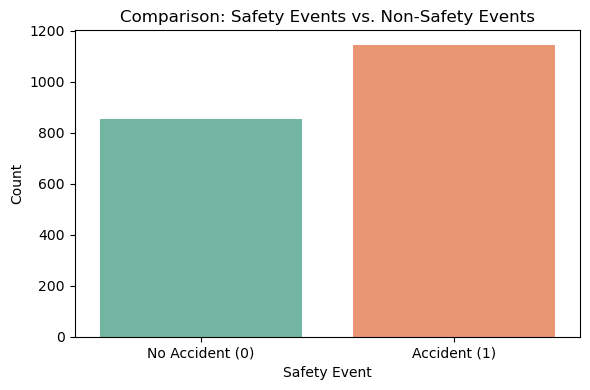

In [8]:
counts = df_1['safety_event'].value_counts()
total_events = len(df_1)
relative_counts = df_1['safety_event'].value_counts(normalize=True) * 100

print("שכיחות מוחלטת:")
print(counts)
print(f"\nסה\"כ אירועים (תצפיות): {total_events}")
print("\nשכיחות יחסית (%):")
for label, val in relative_counts.items():
    print(f"  {label}: {val:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_1, x='safety_event', palette='Set2')

plt.title("Comparison: Safety Events vs. Non-Safety Events")
plt.xlabel("Safety Event")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Accident (0)", "Accident (1)"])

plt.tight_layout()
plt.show()

values range: 18 to 30
mean: 23.18
median: 23.00


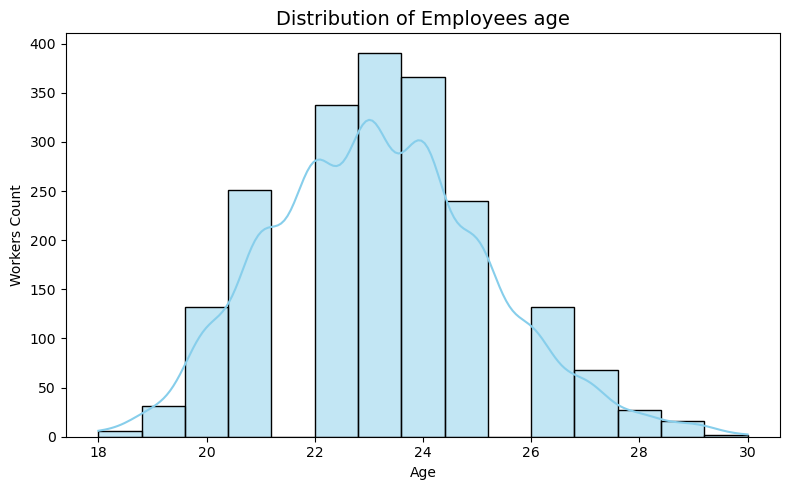

In [9]:
continuous_var = 'age' 

min_val = df_1[continuous_var].min()
max_val = df_1[continuous_var].max()
mean_val = df_1[continuous_var].mean()
median_val = df_1[continuous_var].median()

print(f"values range: {min_val} to {max_val}")
print(f"mean: {mean_val:.2f}")
print(f"median: {median_val:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(data=df_1, x=continuous_var, kde=True, color='skyblue', bins=15)

plt.title(f"Distribution of Employees age", fontsize=14)
plt.xlabel(continuous_var.capitalize())
plt.ylabel("Workers Count")

plt.tight_layout()
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 15px;">
    ניתוח התפלגות המשתנה הרציף - גילאי העובדים
</h3>

<div style="margin-bottom: 20px;">
    <p style="margin: 0; text-align: justify;">
        ההיסטוגרמה מציגה את התפלגות גילאי העובדים במפעל, הנעים בטווח שבין 18 ל-30, כאשר ריכוז הגילאים הגבוה ביותר (מרכז ההתפלגות) נמצא סביב הגילאים 22 עד 25, עם ממוצע של 23.18 וחציון של 23.00.
    </p>
</div>

</div>

In [10]:
y = df_1['safety_event']
X = df_1.drop(columns=['safety_event'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(f"X_train Size: {X_train.shape[0]}")
print(f"X_test Size: {X_test.shape[0]}")

X_train Size: 1400
X_test Size: 600


<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            הכנת הנתונים והגדרת המשתנים למודל הרגרסיה
        </h3>
        <p style="margin: 0; text-align: justify;">
            מתוך כלל הדאטה, בחרנו להוציא את המשתנה הבינארי <b>"האם קרתה תאונה"</b> כיוון שהוא הערך הנחזה. בנוסף, בחרנו להוציא את המשתנה <b>"דירוג העובד"</b> בשל הקורלציה הגבוהה שלו עם המשתנה <b>"ניסיון"</b>, זאת כדי למנוע <b>מולטיקולינאריות</b> במודל.
        </p>
    </div>

</div>

In [11]:
y = df_1['safety_event']

all_features = ['age', 'expirience', 'hour', 'days_c', 'toys_c', 'factories_rand_c', 'months_c']
X = df_1[all_features]

categorical_features = ['days_c', 'toys_c', 'factories_rand_c', 'months_c']
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
X = sm.add_constant(X)
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.10, verbose=True):
    included = ['const'] 
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)
        
        for new_column in excluded:
            try:
                model = sm.Logit(y, X[included + [new_column]]).fit(disp=0)
                new_pval[new_column] = model.pvalues[new_column]
            except Exception:
                new_pval[new_column] = np.nan
        
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'Add  {best_feature:30} with p-value {best_pval:.6f}')

        if len(included) > 1:
            model = sm.Logit(y, X[included]).fit(disp=0)
            variables_to_test = [v for v in included if v != 'const']
            if variables_to_test:
                pvalues = model.pvalues[variables_to_test]
                worst_pval = pvalues.max()
                if worst_pval > threshold_out:
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    changed = True
                    if verbose:
                        print(f'Drop {worst_feature:30} with p-value {worst_pval:.6f}')
        if not changed:
            break
    return included

print("Beginning of picking Stepwise variables ---")
selected_features = stepwise_selection(X_train, y_train)
print("\n Selected Variables:\n", selected_features)
print("="*50)

full_model = sm.Logit(y_train, X_train).fit(disp=0)
final_model = sm.Logit(y_train, X_train[selected_features]).fit()
print("\n" + "="*20 + " Models Performances Comprassion: " + "="*20)
comparison_df = pd.DataFrame({
    'Full Model (All Features)': [full_model.aic, full_model.bic],
    'Stepwise Model (Selected Features)': [final_model.aic, final_model.bic]
}, index=['AIC', 'BIC'])

print(comparison_df.round(2))
print("="*63)

print("\n Model Summary (Stepwise Model Summary)")
print(final_model.summary())

Beginning of picking Stepwise variables ---
Add  hour                           with p-value 0.000000
Add  expirience                     with p-value 0.000000
Add  age                            with p-value 0.000000
Add  days_c_Tuesday                 with p-value 0.000260
Add  months_c_September             with p-value 0.000325
Add  months_c_May                   with p-value 0.000512
Add  toys_c_puzzels                 with p-value 0.011356
Add  factories_rand_c_Huainan       with p-value 0.027538
Add  toys_c_electric_toys           with p-value 0.049833

 Selected Variables:
 ['const', 'hour', 'expirience', 'age', 'days_c_Tuesday', 'months_c_September', 'months_c_May', 'toys_c_puzzels', 'factories_rand_c_Huainan', 'toys_c_electric_toys']
Optimization terminated successfully.
         Current function value: 0.210506
         Iterations 9

==================== Models Performances Comprassion: ====================
     Full Model (All Features)  Stepwise Model (Selected Features)
A

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            המשתנים (Features) שנבחרו למודל הסופי בתהליך ה-Stepwise
        </h3>
        <p style="text-align: justify; margin: 0;">
            בתום תהליך המידול, נבחרו 9 משתנים מסבירים (בתוספת הקבוע const) שנמצאו כבעלי השפעה מובהקת סטטיסטית על הסיכוי להתרחשות תאונה (כולם עם ערך <i>p</i>-value קטן או שווה ל-0.05). 
        </p>
    </div>

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            ניתוח מדדי טיב ההתאמה והשוואת המודלים
        </h3>
        <p style="text-align: justify; margin: 0 0 10px 0;">
            <b>Log-Likelihood (ערך לוג-נראות: -294.71):</b> מדד זה מעיד על מידת ההסתברות שהנתונים האמיתיים אכן יתרחשו תחת המודל שבנינו, וככל שהוא קרוב יותר ל-0 (פחות שלילי), ההתאמה של המודל לדאטה טובה יותר.
        </p>
        <p style="text-align: justify; margin: 0 0 10px 0;">
            <b>AIC:</b> מדד זה מעיד על איכות המודל תוך איזון בין רמת הדיוק שלו לבין מספר המשתנים (מורכבות המודל), כאשר ערך נמוך יותר מצביע על מודל יעיל יותר. (609.42 במודל המצומצם לעומת 619.59 במודל המלא).
        </p>
        <p style="text-align: justify; margin: 0;">
            <b>BIC:</b> בדומה ל-AIC, מדד זה מעיד על יעילות המודל אך מטיל קנס כבד יותר על ריבוי משתנים, כאשר ערך נמוך יותר מסמן מודל אופטימלי. השילוב של ירידה הן ב-AIC והן ב-BIC מוכיח באופן מובהק שתהליך ה-Stepwise ייצר מודל עדיף, מדויק ומזוקק יותר מהמודל המלא. (661.86 במודל המצומצם לעומת 761.18 במודל המלא) 
        </p>
    </div>

<div>
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            משמעות סטיות התקן של המשתנים
        </h3>
        <p style="text-align: justify; margin: 0;">
            עמודת שגיאת התקן (<code>std err</code>) מעידה על רמת הדיוק והיציבות שבה המודל מעריך את המקדם של כל פיצ'ר, או במילים אחרות - מהי רמת השונות הצפויה של המקדם במדגמים חוזרים. סטיות תקן נמוכות מאוד במשתנים הרציפים, כגון <b>0.048</b> עבור ניסיון ו-<b>0.082</b> עבור שעות, מראות שהמודל בטוח מאוד בהערכת המקדמים שלהם בזכות כמות מידע גבוהה. לעומת זאת, סטיות תקן גבוהות יותר במשתני הדמה הקטגוריאליים (למשל, <b>0.440</b> עבור חודש מאי ו-<b>0.430</b> עבור חודש ספטמבר) מעידות על רמת ודאות נמוכה יותר של המודל.  
        </p>
    </div>


</div>

In [12]:
intercept = final_model.params['const']
z = intercept

if 'hour' in selected_features:
    z += final_model.params['hour'] * 2
if 'age' in selected_features:
    z += final_model.params['age'] * 2
if 'expirience' in selected_features:
    z += final_model.params['expirience'] * 2

probability = 1 / (1 + np.exp(-z))

print(f"While the Numeric vars are set to [2] and the Categorized vars are set to [Default] we recieve the following prediction stats:")
print(f"Z-value: {z:.3f}")
print(f"Probability for Accident: {probability*100:.3f}%")


While the Numeric vars are set to [2] and the Categorized vars are set to [Default] we recieve the following prediction stats:
Z-value: 4.698
Probability for Accident: 99.097%


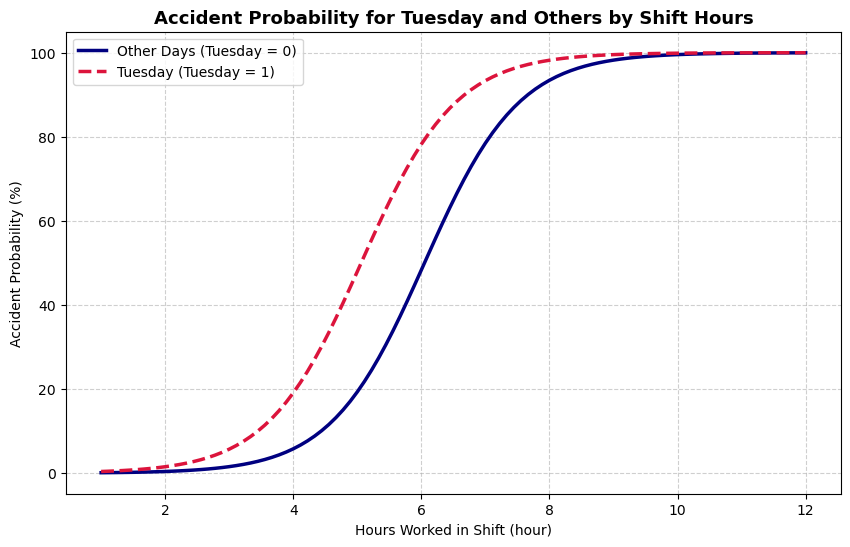

In [13]:
base_df = pd.DataFrame([X_train[selected_features].mean()])
dummy_cols = [c for c in selected_features if c not in ['const', 'hour', 'age', 'expirience']]
base_df[dummy_cols] = 0.0

hours = np.linspace(X_train['hour'].min(), X_train['hour'].max(), 100)
df_g0 = pd.concat([base_df] * 100, ignore_index=True)
df_g1 = df_g0.copy()

df_g0['hour'] = hours
df_g1['hour'] = hours
df_g0['days_c_Tuesday'] = 0.0
df_g1['days_c_Tuesday'] = 1.0

prob_g0 = final_model.predict(df_g0[selected_features])
prob_g1 = final_model.predict(df_g1[selected_features])

plt.figure(figsize=(10, 6))
plt.plot(hours, prob_g0 * 100, label='Other Days (Tuesday = 0)', color='navy', linewidth=2.5)
plt.plot(hours, prob_g1 * 100, label='Tuesday (Tuesday = 1)', color='crimson', linewidth=2.5, linestyle='--')

plt.title('Accident Probability for Tuesday and Others by Shift Hours', fontsize=13, fontweight='bold')
plt.xlabel('Hours Worked in Shift (hour)')
plt.ylabel('Accident Probability (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
             השפעת שעות העבודה במשמרת על הסיכוי לתאונה
        </h3>
        <p style="text-align: justify; margin: 0;">
            מהניתוח של המשתנה הרציף "hour" עולה קשר חיובי וחד-משמעי: ככל שמספר שעות העבודה במשמרת עולה, כך עולה ההסתברות להתרחשות תאונה. בשעות הראשונות של המשמרת (שעות 1-3) ההסתברות לתאונה נמוכה מאוד ושואפת לאפס בכל ימי השבוע, אך החל מהשעה ה-4 נרשמת עלייה חדה ותלולה במיוחד בהסתברות, אשר מגיעה לכמעט 100% לקראת השעה ה-8-9 במשמרת.
        </p>
    </div>

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            השוואה בין יום שלישי לעומת שאר ימי השבוע
        </h3>
        <p style="text-align: justify; margin: 0 0 10px 0;">
            הגרף מציג בבירור כי עקומת ההסתברות של יום שלישי ממוקמת באופן עקבי מעל לעקומה של שאר ימי השבוע.
        </p>
        <p style="text-align: justify; margin: 0;">
            המשמעות הסטטיסטית היא שבימי שלישי הסיכוי לתאונה גבוה יותר בכל נקודת זמן לאורך המשמרת בהשוואה לימים אחרים. הפער המשמעותי ביותר בין שני הקווים מגיע לשיאו באזור שעת העבודה השישית, שם הסיכוי לתאונה ביום שלישי עומד על כ-<b>80%</b>, בעוד שביום רגיל באותה שעה בדיוק הסיכוי עומד על כ-<b>50%</b> בלבד.
        </p>
    </div>

</div>

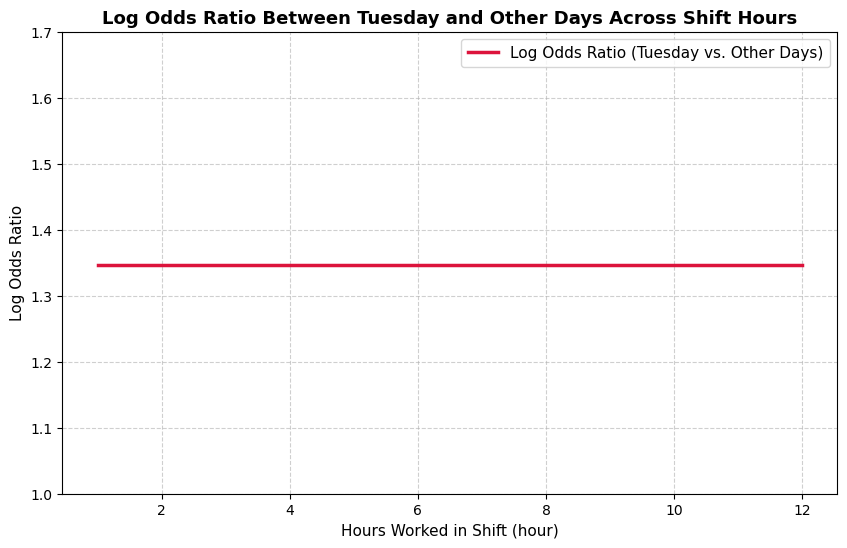

In [14]:
z_g0 = final_model.predict(df_g0[selected_features], which='linear')
z_g1 = final_model.predict(df_g1[selected_features], which='linear')

p_g0 = 1 / (1 + np.exp(-z_g0))
p_g1 = 1 / (1 + np.exp(-z_g1))

odds_g0 = p_g0 / (1 - p_g0)
odds_g1 = p_g1 / (1 - p_g1)

odds_ratio = odds_g1 / odds_g0

log_odds_ratio = np.log(odds_ratio)

plt.figure(figsize=(10, 6))
plt.plot(hours, log_odds_ratio, color='crimson', linewidth=2.5, label='Log Odds Ratio (Tuesday vs. Other Days)')

plt.ylim(1.0, 1.7)

plt.title('Log Odds Ratio Between Tuesday and Other Days Across Shift Hours', fontsize=13, fontweight='bold')
plt.xlabel('Hours Worked in Shift (hour)', fontsize=11)
plt.ylabel('Log Odds Ratio', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="direction: rtl; text-align: right; margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px; text-align: right;">
            הסבר התוצאה
        </h3>
        <p style="text-align: right; margin: 0 0 8px 0;">
            <b>Odds Ratio:</b>
        </p>
        <p style="text-align: right; margin: 0 0 10px 0;">
            לוקחים את ה-Odds של קבוצה אחת ומחלקים אותה ב-Odds של קבוצה אחרת. כך הוא עונה לנו על השאלה: פי כמה הסיכוי להתרחשות האירוע גבוה או נמוך יותר בקבוצה א' בהשוואה לקבוצה ב'.
        </p>
        <p style="text-align: right; margin: 0 0 10px 0;">
            במקרה שלנו, פי כמה הסיכוי להתרחשות תאונה ביום שלישי גבוה או נמוך ביחס להתרחשות תאונה ביום שהוא לא שלישי.
        </p>
        <p style="text-align: right; margin: 0 0 10px 0;">
            ניתן לראות בגרף שהיחס נשמר בצורה אחידה ואין "קפיצות" של הקו.
        </p>
    </div>

<div style="direction: rtl; text-align: right;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px; text-align: right;">
            מה משמעות הערך שקיבלנו בגרף?
        </h3>
        <p style="text-align: right; margin-bottom: 12px;">
            <b>בסולם ה-Log-Odds (הגרף):</b> הקו מופיע בערך הקבוע <b>1.3462</b> מכיוון שהגרף מציג את ההפרש בסולם הלוגריתמי, שהוא בדיוק המקדם הסטטיסטי של יום שלישי במודל.
        </p>
        <p style="text-align: right; margin-bottom: 12px;">
            <b>בסולם ה-Odds Ratio (יחס הסיכויים):</b> כדי לתרגם את ה-Log-Odds למספר כפולי ("פי כמה"), מפעילים אקספוננט: 
            <code style="direction: ltr; display: inline-block;">e^1.3462 ≈ 3.84</code>.
        </p>
    </div>

</div>

In [15]:
y_test_prob = final_model.predict(X_test[selected_features])

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

valid_idx = np.where(tpr >= 0.8)[0]

opt_threshold = thresholds[valid_idx[0]]
achieved_sensitivity = tpr[valid_idx[0]]

print(f"Optimal threshold for Sensitivity >= 0.8: {opt_threshold:.4f}")
print(f"Achieved Sensitivity (TPR): {achieved_sensitivity:.4f}")

Optimal threshold for Sensitivity >= 0.8: 0.7946
Achieved Sensitivity (TPR): 0.8105


<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
             ערך סף עבור Sensitivity ≥ 0.8 ב-Test Set
        </h3>
        <p style="text-align: justify; margin: 0 0 10px 0;">
            מניתוח עקומת ה-ROC על גבי נתוני המבחן (Test Set), ערך הסף הנדרש להבטחת רגישות של לפחות 80% הוא:
        </p>
        <div style="text-align: center; font-size: 1.1em; font-weight: bold; background-color: #eef7f8; padding: 12px; border-radius: 6px; border-right: 4px solid #1a5f7a; margin: 15px 0;">
            Threshold = 0.7946 &nbsp;&nbsp;|&nbsp;&nbsp; Achieved Sensitivity = 81.05% 
        </div>
    </div>

<div>
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            הסבר ומשמעות התוצאה
        </h3>
        <ul style="margin: 0; padding-right: 20px;">
            <li style="margin-bottom: 8px;">
                <b>משמעות הרגישות (Sensitivity):</b> הגדרת הסף בערך <b>0.7946</b> מבטיחה שהמודל יזהה ויסווג בהצלחה <b>81.05%</b> מכלל מקרי התאונות האמיתיים שהתרחשו ב-Test Set.
            </li>
            <li style="margin-bottom: 8px;">
                <b>כלל ההכרעה במודל:</b> כל תצפית ב-Test Set שבה ההסתברות המחושבת על ידי המודל לתאונה תהיה 0.7946 ומעלה תסווג כ"תאונה" (1), וכל תצפית מתחת לסף זה תסווג כ"אין תאונה" (0).
            </li>
            <li>
                <b>אופטימיזציה:</b> זהו ערך הסף המקסימלי (האופטימלי) שעדיין מאפשר לעמוד בדרישת הסף של לפחות 80% זיהוי תאונות, מבלי להוריד את הסף לחינם ולהגדיל את שיעור אזעקות השווא (False Positives).
            </li>
        </ul>
    </div>

</div>

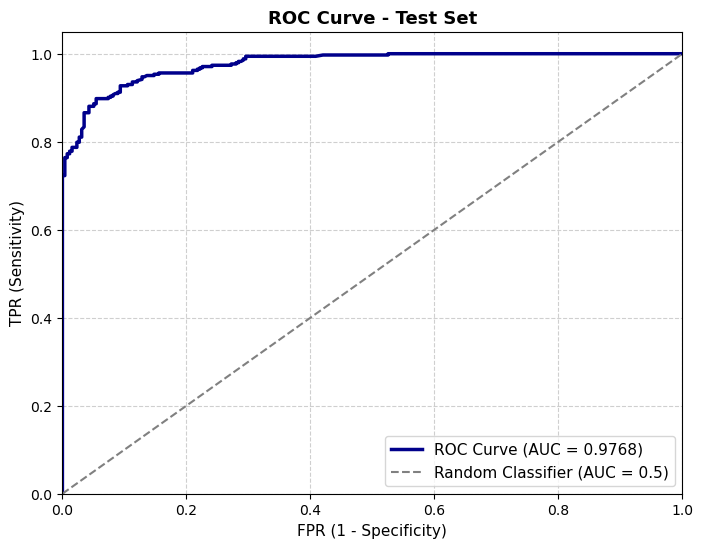

In [16]:
y_test_prob = final_model.predict(X_test[selected_features])

roc_auc = roc_auc_score(y_test, y_test_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkblue', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (1 - Specificity)', fontsize=11)
plt.ylabel('TPR (Sensitivity)', fontsize=11)
plt.title('ROC Curve - Test Set', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=11)

plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            תשובה לסעיף 11: עקומת ROC וחישוב מדד ה-AUC ב-Test Set
        </h3>
        <p style="text-align: justify; margin: 0 0 10px 0;">
            מניתוח ביצועי המודל הסופי על גבי נתוני המבחן (Test Set), התקבלה עקומת ROC המתוארת בגרף, והשטח מתחת לעקומה (AUC) שחושב הוא:
        </p>
        <div style="text-align: center; font-size: 1.1em; font-weight: bold; background-color: #eef7f8; padding: 12px; border-radius: 6px; border-right: 4px solid #1a5f7a; margin: 15px 0;">
            AUC = 0.9768
        </div>
    </div>

<div>
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            ניתוח והסבר המדדים
        </h3>
        <ul style="margin: 0; padding-right: 20px;">
            <li style="margin-bottom: 8px;">
                <b>תיאור עקומת ה-ROC:</b> העקומה נצמדת באופן מובהק לפינה השמאלית-עליונה של הגרף. משמעות הדבר היא שהמודל מצליח להשיג שיעור זיהוי נכון גבוה מאוד כבר ברמות נמוכות מאוד של אזעקות שווא.
            </li>
            <li style="margin-bottom: 8px;">
                <b>משמעות ערך ה-AUC:</b> המדד AUC מייצג את יכולת ההפרדה של המודל. ערך של <b>0.9768</b> (הקרוב מאוד ל-1.0) מראה כי בהינתן תצפית אקראית של תאונה ותצפית אקראית של "אין תאונה", ההסתברות שהמודל יעניק ציון הסתברות גבוה יותר למקרה התאונה היא <b>97.68%</b>.
            </li>
        </ul>
    </div>

</div>

In [17]:
features_no_cat = [f for f in selected_features if f != 'days_c_Tuesday']

model_no_cat = sm.Logit(y_train, X_train[features_no_cat]).fit(disp=False)

y_prob_no_cat = model_no_cat.predict(X_test[features_no_cat])

auc_no_cat = roc_auc_score(y_test, y_prob_no_cat)
fpr_no_cat, tpr_no_cat, _ = roc_curve(y_test, y_prob_no_cat)

print(f"AUC without Categorical Variable (days_c_Tuesday): {auc_no_cat:.4f}")

AUC without Categorical Variable (days_c_Tuesday): 0.9765


In [18]:
features_no_cont = [f for f in selected_features if f != 'hour']

model_no_cont = sm.Logit(y_train, X_train[features_no_cont]).fit(disp=False)

y_prob_no_cont = model_no_cont.predict(X_test[features_no_cont])

auc_no_cont = roc_auc_score(y_test, y_prob_no_cont)
fpr_no_cont, tpr_no_cont, _ = roc_curve(y_test, y_prob_no_cont)

print(f"AUC without Continuous Variable (hour): {auc_no_cont:.4f}")

AUC without Continuous Variable (hour): 0.6341


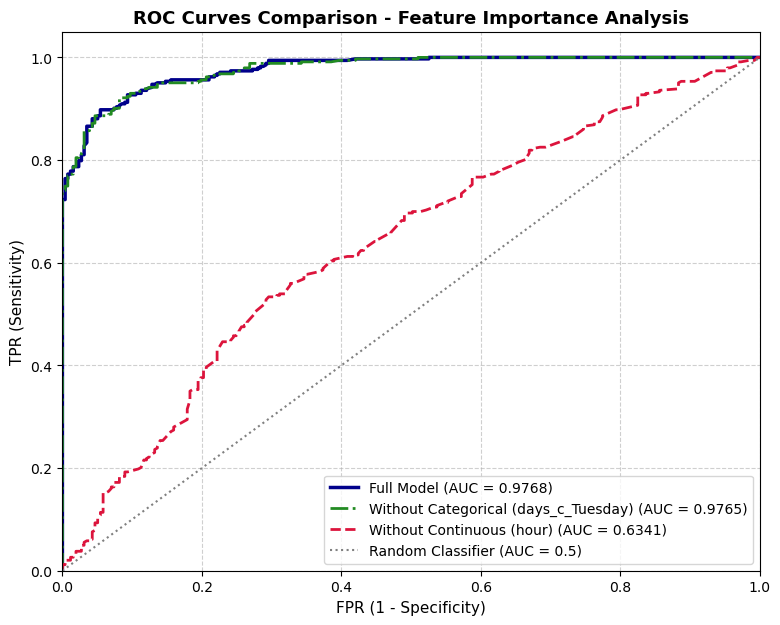

In [19]:
plt.figure(figsize=(9, 7))

plt.plot(fpr, tpr, color='darkblue', lw=2.5, 
         label=f'Full Model (AUC = {roc_auc:.4f})')

plt.plot(fpr_no_cat, tpr_no_cat, color='forestgreen', lw=2, linestyle='-.', 
         label=f'Without Categorical (days_c_Tuesday) (AUC = {auc_no_cat:.4f})')

plt.plot(fpr_no_cont, tpr_no_cont, color='crimson', lw=2, linestyle='--', 
         label=f'Without Continuous (hour) (AUC = {auc_no_cont:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (1 - Specificity)', fontsize=11)
plt.ylabel('TPR (Sensitivity)', fontsize=11)
plt.title('ROC Curves Comparison - Feature Importance Analysis', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=10)

plt.show()

<div style="direction: rtl; text-align: right; font-family: Arial, sans-serif; line-height: 1.8; max-width: 800px; margin: 0 auto; color: #333333;">

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
             השוואת ערכי ה-AUC בין המודלים
        </h3>
        <ul style="margin: 0; padding-right: 20px;">
            <li style="margin-bottom: 6px;">
                <b>המודל המלא (Full Model):</b> <code>AUC = 0.9768</code>
            </li>
            <li style="margin-bottom: 6px;">
                <b>מודל ללא המשתנה הקטגוריאלי (days_c_Tuesday):</b> <code>AUC = 0.9765</code>
            </li>
            <li>
                <b>מודל ללא המשתנה הרציף (hour):</b> <code>AUC = 0.6341</code>
            </li>
        </ul>
    </div>

<div style="margin-bottom: 25px;">
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
             ניתוח השינויים: מי הושפע יותר?
        </h3>
        <ul style="margin: 0; padding-right: 20px;">
            <li style="margin-bottom: 10px;">
                <b>הוצאת המשתנה הקטגוריאלי (<code>days_c_Tuesday</code>):</b> הנתונים מראים כי הירידה ב-AUC זניחה לחלוטין (מ-0.9768 ל-0.9765, ירידה של כ-0.03% בלבד). העקומה הירוקה חופפת כמעט במידה מלאה לעקומה הכחולה של המודל המלא.
            </li>
            <li>
                <b>הוצאת המשתנה הרציף (<code>hour</code>):</b> הוצאת המשתנה שעות המשמרת הובילה לקריסה בביצועי המודל. ערך ה-AUC צנח מ-0.9768 ל-0.6341 (ירידה של כ-35%). העקומה האדומה התקרבה באופן משמעותי לקו האלכסון האקראי.
            </li>
        </ul>
    </div>

<div>
        <h3 style="color: #1a5f7a; border-bottom: 2px solid #1a5f7a; padding-bottom: 8px; margin-bottom: 12px;">
            מה זה אומר לדעתנו? 
        </h3>
        <ul style="margin: 0; padding-right: 20px;">
            <li style="margin-bottom: 8px;">
                <b>חשיבות יחסית של המשתנים:</b> המשתנה הרציף hour הוא הכוח המנבא המרכזי והקריטי ביותר במודל. ללא המידע על משך השעות במשמרת, המודל מאבד כמעט את כל יכולת ההפרדה והחיזוי שלו לגבי אירוע תאונה.
            </li>
            <li style="margin-bottom: 8px;">
                <b>תרומה שולית של המשתנה הקטגוריאלי:</b> המשתנה הקטגוריאלי days_c_Tuesday מציג תרומה שולית זניחה מאוד ליכולת הניבוי הכללית (AUC) כשהמשתנה הרציף נוכח, שכן המידע העיקרי המסביר את הסיכון לתאונה נלמד כבר מתוך שעות העבודה המצטברות במשמרת.
            </li>
        </ul>
    </div>

</div>